In [45]:
import sys
sys.path.insert(1, '/home/fainx/MyPythonLibrary/MAR-RECAP/libmar/')
import climbasis as climb
from climbasis import *
import domain as dom
import myplot
import numpy.ma as ma
from myplot import *
import obsinfo as obs
from obsinfo import *
from datetime import datetime
import mar
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
# import dask

In [46]:
iyr=1980;fyr=2024
domain='GRf'
latS,latN,lonW,lonE,latlim,lonlim=dom.coord_domain(domain)  
print(latS,latN,lonW,lonE)

# Removed pixels on domain boundaries
k =10

36 41 67 78


In [47]:
# Chukurbashi Glacier coordinates:
chuk_lat = 39.250066
chuk_lon = 73.557790

In [48]:
season_list = ["DJF", "MAM", "JJA", "SON"]

In [49]:
domain_2 = 'GRp'
# domain_3 = 'GRp_bug'

In [50]:
sourceData_1='/bettik/PROJECTS/pr-regional-climate/santolam/MARout_post/' + domain_2 +'/spin2/work/monthly/'
sourceData_2='/bettik/PROJECTS/pr-regional-climate/fainx/'
# sourceData_3='/bettik/PROJECTS/pr-regional-climate/santolam/'
folder_figure = '/bettik/PROJECTS/pr-regional-climate/fainx/figures/' + domain_2 +'/'

In [51]:
# MAR topography
sourceDataGrid='/home/amoryc/'
fileName_grF='NST.2000.01.01.00.GRp.nc'
ds_grF= xr.open_dataset(sourceDataGrid+fileName_grF)

# Enlever k pixels sur les contours
ds_lon=ds_grF.LON[k:-k,k:-k]
ds_lat=ds_grF.LAT[k:-k,k:-k]
ds_SH=ds_grF.SH[k:-k,k:-k]
ds_ICE=ds_grF.ICE[k:-k,k:-k]

ds_lon = ds_lon.rename({"y": "Y", "x": "X"})
ds_lat = ds_lat.rename({"y": "Y", "x": "X"})
ds_SH = ds_SH.rename({"y": "Y", "x": "X"})
ds_ICE = ds_ICE.rename({"y": "Y", "x": "X"})

ds_lon = ds_lon.assign_coords(X=np.round(ds_lon.X.values))
ds_lon = ds_lon.assign_coords(Y=np.round(ds_lon.Y.values))

ds_lat = ds_lat.assign_coords(X=np.round(ds_lat.X.values))
ds_lat = ds_lat.assign_coords(Y=np.round(ds_lat.Y.values))

ds_SH = ds_SH.assign_coords(X=np.round(ds_SH.X.values))
ds_SH = ds_SH.assign_coords(Y=np.round(ds_SH.Y.values))

ds_ICE = ds_ICE.assign_coords(X=np.round(ds_ICE.X.values))
ds_ICE = ds_ICE.assign_coords(Y=np.round(ds_ICE.Y.values))

In [52]:
# Identifier les indices X et Y correspondant au point de grille ou se trouve le glacier Chukurbashi 

# distance sur grille
dist = np.sqrt((ds_lat - chuk_lat)**2 + (ds_lon - chuk_lon)**2)

# index 1D du minimum
idx_1d = dist.argmin().item()

# conversion en indices 2D (Y, X)
iY, iX = np.unravel_index(idx_1d, dist.shape)


print("Caratéristique de la maille MAR ou se trouve le glacier Chukurbashi ")
print("Indice Y :", iY)
print("Indice X :", iX)
print("Latitude :", ds_lat[iY, iX].item())
print("Longitude :", ds_lon[iY, iX].item())
print("Altitude :", ds_SH[iY, iX].item())

Caratéristique de la maille MAR ou se trouve le glacier Chukurbashi 
Indice Y : 37
Indice X : 62
Latitude : 39.23432540893555
Longitude : 73.51907348632812
Altitude : 4659.54541015625


In [53]:
dist = np.sqrt((ds_lat - chuk_lat)**2 + (ds_lon - chuk_lon)**2)
idx_1d = dist.argmin().item()
iY, iX = np.unravel_index(idx_1d, dist.shape)

iX_N= iX
iY_N = iY+4

print("Caratéristique de la maille MAR voisine du glacier Chukurbashi la plus haute")
print("Indice Y :", iY_N)
print("Indice X :", iX_N)
print("Latitude :", ds_lat[iY_N, iX_N].item())
print("Longitude :", ds_lon[iY_N, iX_N].item())
print("Altitude :", ds_SH[iY_N, iX_N].item())
print("Ice% :", ds_ICE[iY_N, iX_N].item())

Caratéristique de la maille MAR voisine du glacier Chukurbashi la plus haute
Indice Y : 41
Indice X : 62
Latitude : 39.48607635498047
Longitude : 73.5234375
Altitude : 5241.6201171875
Ice% : 62.626258850097656


In [54]:
dist = np.sqrt((ds_lat - chuk_lat)**2 + (ds_lon - chuk_lon)**2)
idx_1d = dist.argmin().item()
iY, iX = np.unravel_index(idx_1d, dist.shape)

iX_S= iX+4
iY_S = iY-4

print("Caratéristique de la maille MAR voisine du glacier Chukurbashi la plus haute")
print("Indice Y :", iX_S)
print("Indice X :", iX_S)
print("Latitude :", ds_lat[iY_S, iX_S].item())
print("Longitude :", ds_lon[iY_S, iX_S].item())
print("Altitude :", ds_SH[iY_S, iX_S].item())
print("Ice% :", ds_ICE[iY_S, iX_S].item())

Caratéristique de la maille MAR voisine du glacier Chukurbashi la plus haute
Indice Y : 66
Indice X : 66
Latitude : 38.97876739501953
Longitude : 73.83859252929688
Altitude : 5067.13232421875
Ice% : 16.1616153717041


/tmp/ipykernel_513389/2133389860.py:52: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


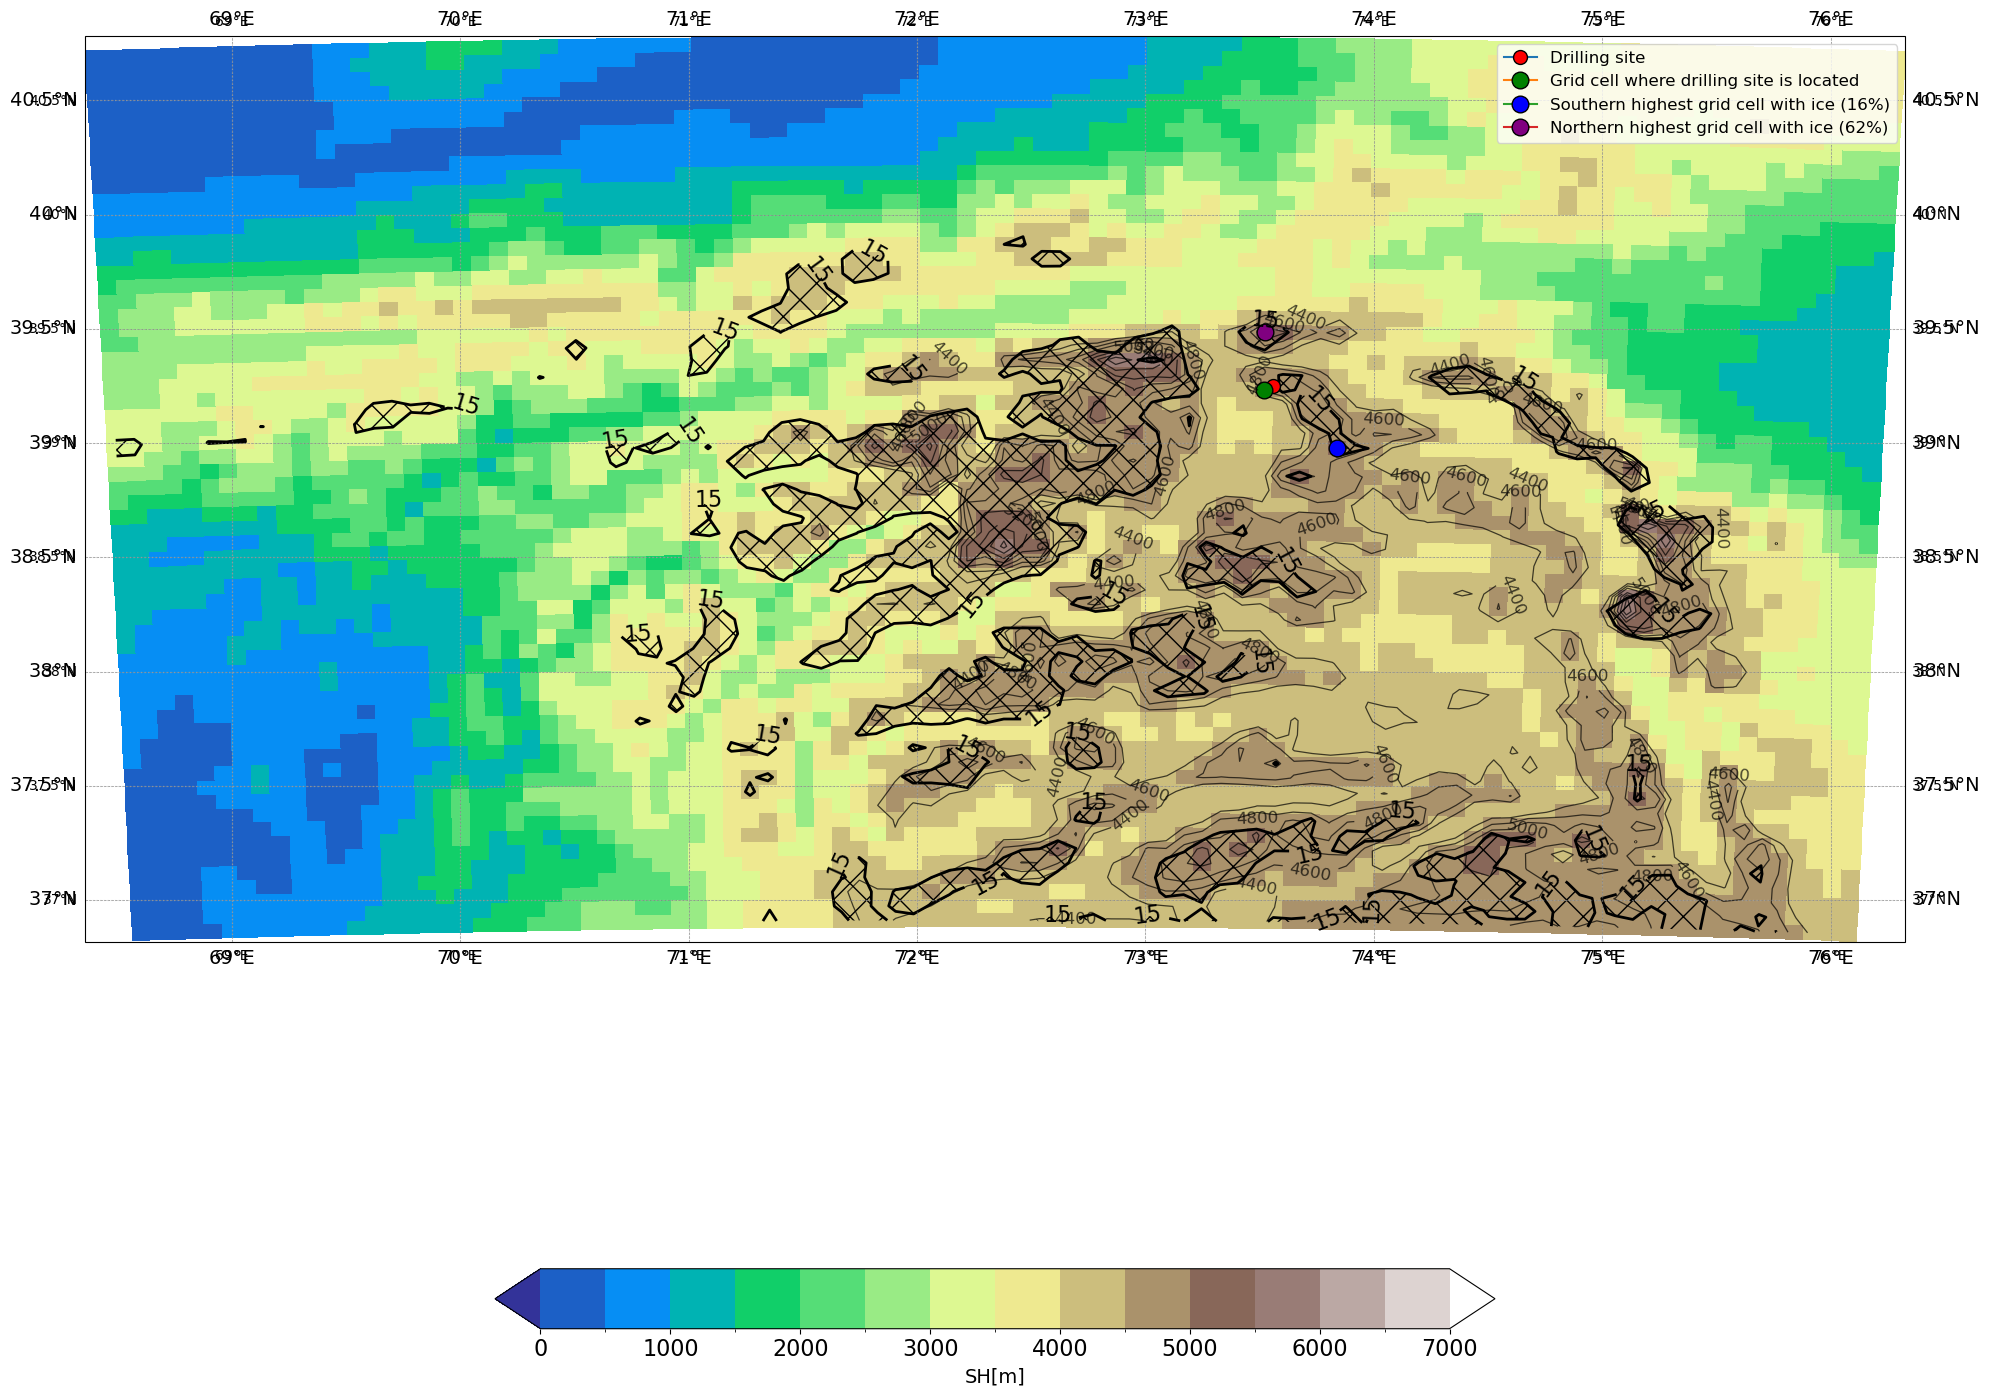

In [58]:
## ice_level=32# % of ice on grid cell

clevs=np.arange(0,7500,500)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(20, 20),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[10,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())

ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)

SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[4400,4600,4800,5000,5200,5400,5600,5800,6000,6200,6400,6600,6800,7000],
                             colors="k", linewidths=0.9, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")
 
# ax.set_extent([71, 72, 39.4, 40], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="lightgray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Chukurbashi drilling site: red dot
ax.plot(chuk_lon, chuk_lat,
        marker='o', markersize=10,
        label='Drilling site',
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())


# point de grille ou se trouve Chukurbashi 
ax.plot(ds_lon[iY, iX], ds_lat[iY, iX],
        marker='o', markersize=12,
        label='Grid cell where drilling site is located',
        markeredgecolor='black', markerfacecolor='green',
        transform=ccrs.PlateCarree())


# SOUTH nearest grid cell with ice :
ax.plot(ds_lon[iY_S, iX_S], ds_lat[iY_S, iX_S],
        marker='o', markersize=12,
        label='Southern highest grid cell with ice (16%)',       
        markeredgecolor='black', markerfacecolor='blue',
        transform=ccrs.PlateCarree())

# # NORTH nearest grid cell with ice 
ax.plot(ds_lon[iY_N, iX_N], ds_lat[iY_N, iX_N],
        marker='o', markersize=12,
        label='Northern highest grid cell with ice (62%)',       
        markeredgecolor='black', markerfacecolor='purple',
        transform=ccrs.PlateCarree())

ax.legend(loc="upper right", fontsize=12)

plt.show()

/tmp/ipykernel_513389/2623212834.py:53: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


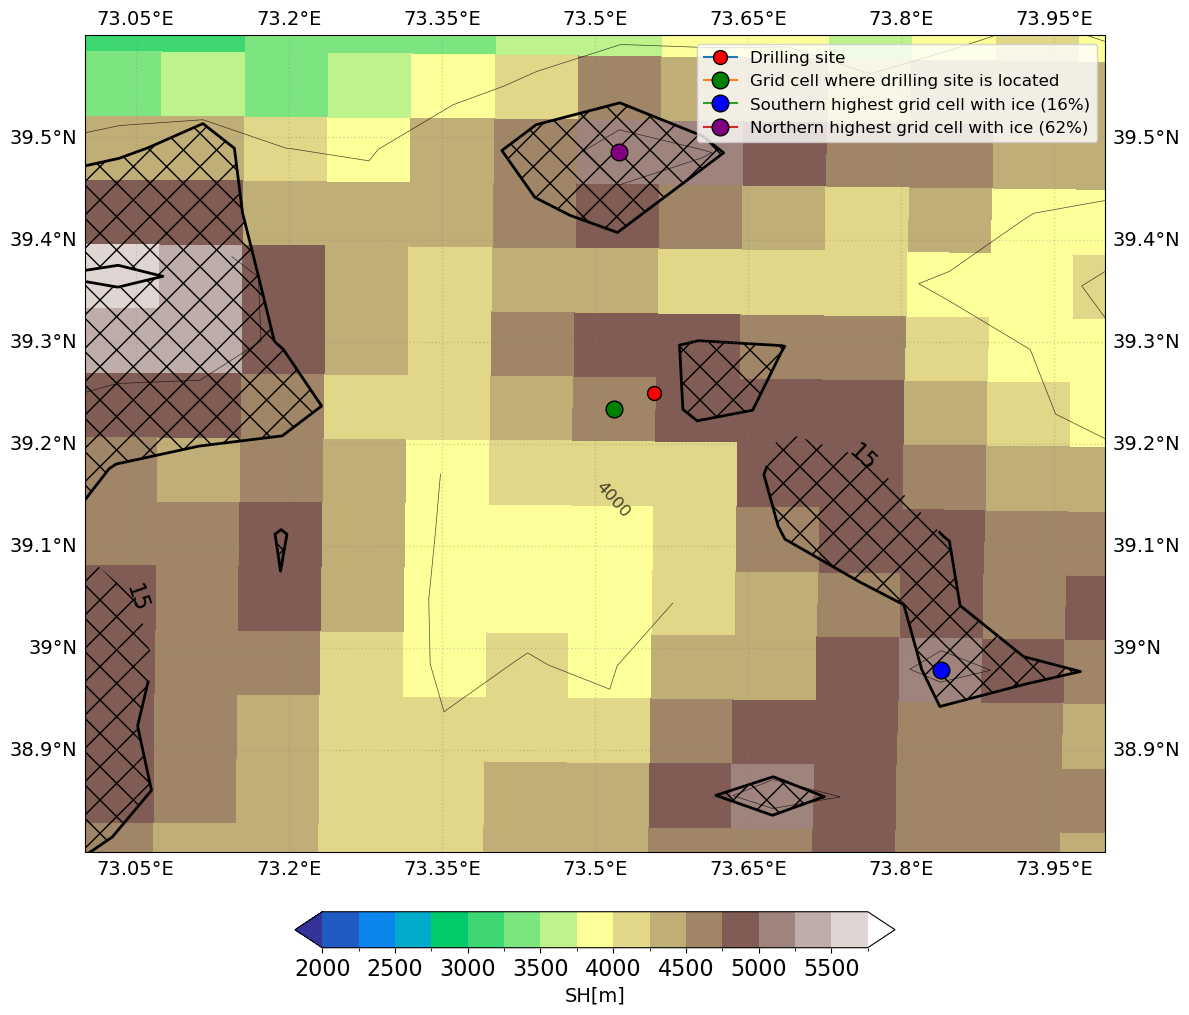

In [56]:
ice_level=15# % of ice on grid cell

clevs=np.arange(2000,6000, 250)
cmap_mod = plt.get_cmap('terrain')
norm = mcolors.BoundaryNorm(boundaries=clevs, ncolors=cmap_mod.N, extend="both")

fig, ax = plt.subplots(figsize=(12, 12),
                         subplot_kw={'projection': ccrs.PlateCarree()})


im = ax.pcolormesh(ds_lon, ds_lat, ds_SH,
                       transform=ccrs.PlateCarree(), cmap=cmap_mod,norm=norm,shading='auto')
# ax.add_feature(cfeature.COASTLINE)
# ax.add_feature(cfeature.BORDERS, linestyle=':')

ICE1=ax.contourf(ds_lon, ds_lat,ds_ICE,
            levels=[0,ice_level,100],
            hatches=['','X','X'],
            colors="none",
            transform=ccrs.PlateCarree())

#    ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', linestyle='--')
ax.set_aspect(1.0)
SH1 = ax.contour(ds_lon, ds_lat, ds_SH,
                             levels=[1000,2000,3000,4000,5000,6000],
                             colors="k", linewidths=0.5, alpha=0.7,
                             transform=ccrs.PlateCarree())
ax.clabel(SH1, inline=True, fontsize=12, fmt="%d")
    
ICE2= ax.contour(ds_lon, ds_lat, ds_ICE,
                    levels=[ice_level],
                    colors="black", linewidths=2.0, alpha=1.0,
                    transform=ccrs.PlateCarree())

ax.clabel(ICE2, inline=True, fontsize=16, fmt="%d")

# Latitude : 39.23432540893555
# Longitude : 73.51907348632812
ax.set_extent([73, 74, 38.8, 39.6], crs=ccrs.PlateCarree())

gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True,
                          linewidth=1, color="gray", alpha=0.3, linestyle=":")
gl.xlabel_style = {"size": 14}
gl.ylabel_style = {"size": 14}

  
cbar_ax = fig.add_axes([0.25, 0.08, 0.5, 0.03])  # [left, bottom, width, height]
cbar = fig.colorbar(im, cax=cbar_ax, orientation="horizontal")
cbar.set_label(f"{'SH'}[{'m'}]", fontsize=14)
cbar.ax.tick_params(labelsize=16)

fig.subplots_adjust(left=0.2, right=0.8, top=0.95, bottom=0.1, wspace=0.05, hspace=0.2)
plt.tight_layout()

# Chukurbashi drilling site: red dot
ax.plot(chuk_lon, chuk_lat,
        marker='o', markersize=10,
        label='Drilling site',
        markeredgecolor='black', markerfacecolor='red',
        transform=ccrs.PlateCarree())

# point de grille ou se trouve Chukurbashi 
ax.plot(ds_lon[iY, iX], ds_lat[iY, iX],
        marker='o', markersize=12,
        label='Grid cell where drilling site is located',
        markeredgecolor='black', markerfacecolor='green',
        transform=ccrs.PlateCarree())


# SOUTH nearest grid cell with ice :
ax.plot(ds_lon[iY_S, iX_S], ds_lat[iY_S, iX_S],
        marker='o', markersize=12,
        label='Southern highest grid cell with ice (16%)',       
        markeredgecolor='black', markerfacecolor='blue',
        transform=ccrs.PlateCarree())

# # NORTH nearest grid cell with ice 
ax.plot(ds_lon[iY_N, iX_N], ds_lat[iY_N, iX_N],
        marker='o', markersize=12,
        label='Northern highest grid cell with ice (62%)',       
        markeredgecolor='black', markerfacecolor='purple',
        transform=ccrs.PlateCarree())


ax.legend(loc="upper right", fontsize=12)
plt.show()

### MAR datasets

In [12]:
variable='TTZ'

ds_TTZ = xr.open_mfdataset(sourceData_1 + "TTZ_monmean_MARv3.14_ER5_spin2_GRp_*.nc").isel(ZTQLEV=0).TTZ.load()

ds_TTZ = ds_TTZ.assign_coords(X=np.round(ds_TTZ.X.values))
ds_TTZ = ds_TTZ.assign_coords(Y=np.round(ds_TTZ.Y.values))
ds_TTZ = ds_TTZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_TTZ = ds_TTZ[:,k:-k,k:-k]

In [13]:
variable='RF'

ds_RF = xr.open_mfdataset(sourceData_1 + "RF_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RF.load()

ds_RF = ds_RF.assign_coords(X=np.round(ds_RF.X.values))
ds_RF = ds_RF.assign_coords(Y=np.round(ds_RF.Y.values))
ds_RF = ds_RF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RF = ds_RF[:,k:-k,k:-k]

In [14]:
variable='SF'

ds_SF = xr.open_mfdataset(sourceData_1 + "SF_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SF.load()

ds_SF = ds_SF.assign_coords(X=np.round(ds_SF.X.values))
ds_SF = ds_SF.assign_coords(Y=np.round(ds_SF.Y.values))
ds_SF = ds_SF.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SF = ds_SF[:,k:-k,k:-k]

In [15]:
variable='ME' 

ds_ME = xr.open_mfdataset(sourceData_1 + "ME_monsum_MARv3.14_ER5_spin2_GRp_*.nc").ME.isel(SECTOR1_1=0).load()

ds_ME = ds_ME.assign_coords(X=np.round(ds_ME.X.values))
ds_ME = ds_ME.assign_coords(Y=np.round(ds_ME.Y.values))
ds_ME = ds_ME.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_ME = ds_ME[:,k:-k,k:-k]
ds_ME = - ds_ME

In [16]:
variable='SMB' 
#"Surface Mass Balance (SMB~SF+RF-RU-SU-SW)" 

ds_SMB = xr.open_mfdataset(sourceData_1 + "SMB_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SMB.isel(SECTOR=0).load()

ds_SMB = ds_SMB.assign_coords(X=np.round(ds_SMB.X.values))
ds_SMB = ds_SMB.assign_coords(Y=np.round(ds_SMB.Y.values))
ds_SMB = ds_SMB.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SMB = ds_SMB[:,k:-k,k:-k]

In [17]:
variable='SW' 
# Surface Water

ds_SW = xr.open_mfdataset(sourceData_1 + "SW_monsum_MARv3.14_ER5_spin2_GRp_*.nc").SW.isel(SECTOR1_1=0).load()

ds_SW = ds_SW.assign_coords(X=np.round(ds_SW.X.values))
ds_SW = ds_SW.assign_coords(Y=np.round(ds_SW.Y.values))
ds_SW = ds_SW.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_SW = ds_SW[:,k:-k,k:-k]

In [18]:
variable='RU' 
# Run Off

ds_RU = xr.open_mfdataset(sourceData_1 + "RU_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RU.isel(SECTOR=0).load()

ds_RU = ds_RU.assign_coords(X=np.round(ds_RU.X.values))
ds_RU = ds_RU.assign_coords(Y=np.round(ds_RU.Y.values))
ds_RU = ds_RU.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RU = ds_RU[:,k:-k,k:-k]

In [19]:
variable='RZ' 
# Refreezing // il faut un monSUM pour RW

ds_RZ = xr.open_mfdataset(sourceData_1 + "RZ_monsum_MARv3.14_ER5_spin2_GRp_*.nc").RZ.isel(SECTOR1_1=0).load()

ds_RZ = ds_RZ.assign_coords(X=np.round(ds_RZ.X.values))
ds_RZ = ds_RZ.assign_coords(Y=np.round(ds_RZ.Y.values))
ds_RZ = ds_RZ.rename({'TIME': 'time'})

# Enlever k pixels sur les contours
ds_RZ = ds_RZ[:,k:-k,k:-k]

In [20]:
variable='SU' 
# SMB = SF - ME +RZ - SU - SW

ds_SU = -(ds_SF - (-ds_ME) + ds_RZ - ds_SW - ds_SMB)

## Sorties de MAR au point de Grille Chukurbashi Glacier

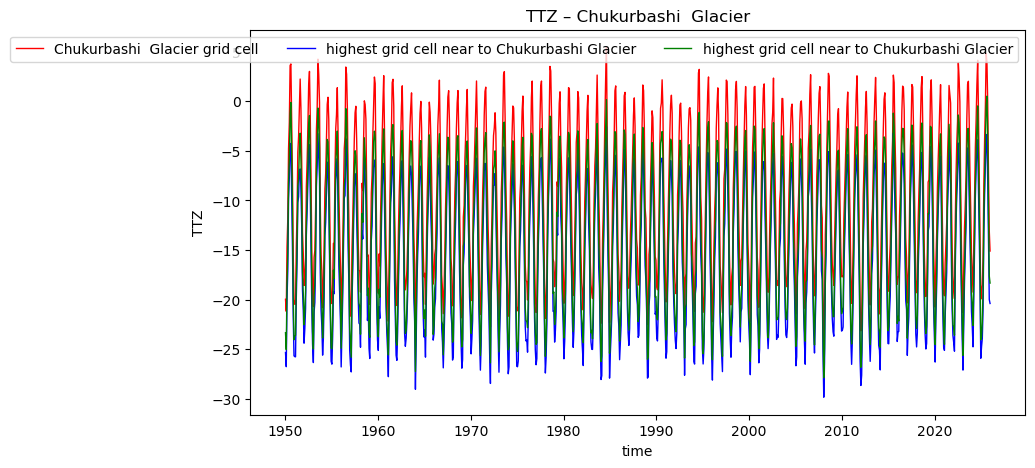

In [21]:
# TTZ at Chukurbashi 

plt.figure(figsize=(10,5))

ds_TTZ_chuk =  ds_TTZ.isel(Y=iY, X=iX)
ds_TTZ_chuk.plot(label="Chukurbashi  Glacier grid cell", linewidth=1, color="red")

ds_TTZ_N =  ds_TTZ.isel(Y=iY_N, X=iX_N)
ds_TTZ_N.plot(label="highest grid cell near to Chukurbashi Glacier", linewidth=1, color="blue")

ds_TTZ_S =  ds_TTZ.isel(Y=iY_S, X=iX_S)
ds_TTZ_S.plot(label="highest grid cell near to Chukurbashi Glacier", linewidth=1, color="green")


plt.legend(ncol=3)
plt.title("TTZ – Chukurbashi  Glacier")
plt.ylabel("TTZ")
plt.show()

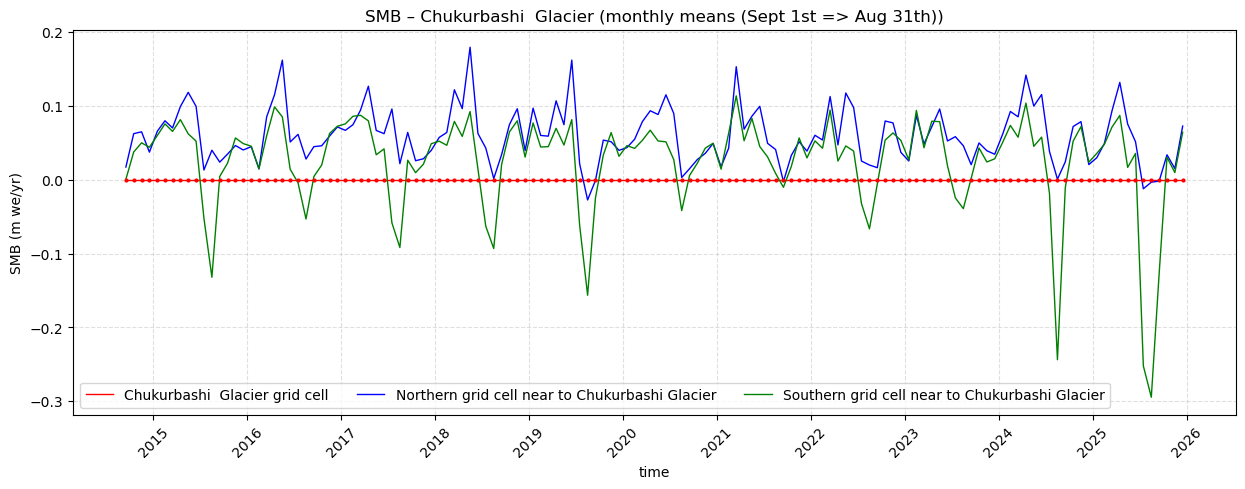

In [22]:
#SMB mensuel 

plt.figure(figsize=(15,5))

ds_SMB_chuk = ds_SMB.isel(Y=iY, X=iX).sel(time=slice("2014-09-01", "2025-12-31"))/1000
ds_SMB_N = ds_SMB.isel(Y=iY_N, X=iX_N).sel(time=slice("2014-09-01", "2025-12-31"))/1000
ds_SMB_S = ds_SMB.isel(Y=iY_S, X=iX_S).sel(time=slice("2014-09-01", "2025-12-31"))/1000

ds_SMB_chuk.plot(label="Chukurbashi  Glacier grid cell", linewidth=1, color="red")
ds_SMB_N.plot(label="Northern grid cell near to Chukurbashi Glacier", linewidth=1, color="blue")
ds_SMB_S.plot(label="Southern grid cell near to Chukurbashi Glacier", linewidth=1, color="green")

plt.plot(ds_SMB_chuk.time,
         ds_SMB_chuk,
         'o', color='red', markersize=2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – Chukurbashi  Glacier (monthly means (Sept 1st => Aug 31th))")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

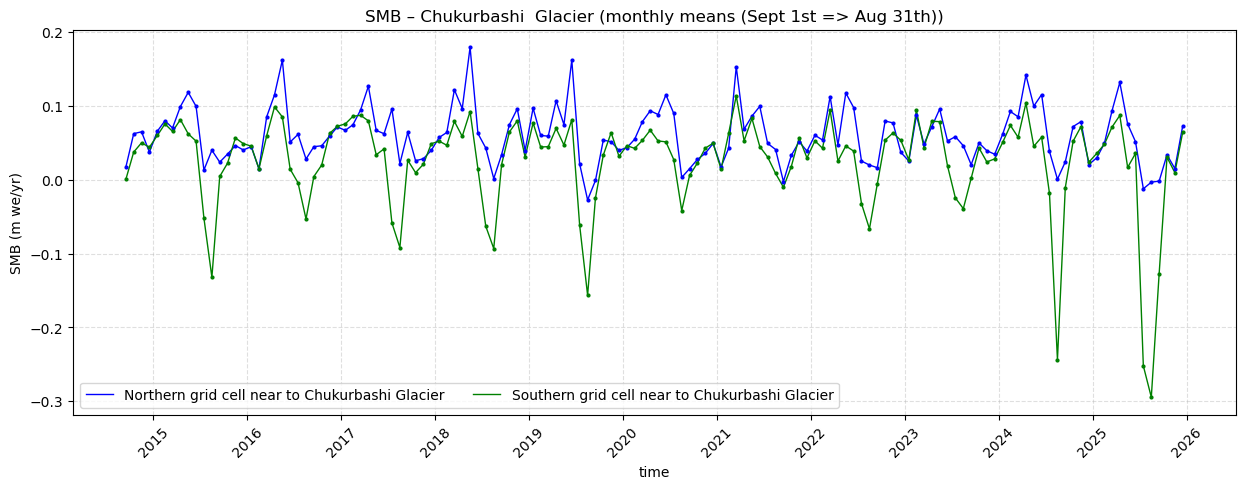

In [23]:
#SMB mensuel 

plt.figure(figsize=(15,5))

ds_SMB_N = ds_SMB.isel(Y=iY_N, X=iX_N).sel(time=slice("2014-09-01", "2025-12-31"))/1000
ds_SMB_S = ds_SMB.isel(Y=iY_S, X=iX_S).sel(time=slice("2014-09-01", "2025-12-31"))/1000

ds_SMB_N.plot(label="Northern grid cell near to Chukurbashi Glacier", linewidth=1, color="blue")
ds_SMB_S.plot(label="Southern grid cell near to Chukurbashi Glacier", linewidth=1, color="green")



plt.plot(ds_SMB_N.time,
         ds_SMB_N,
         'o', color='blue', markersize=2)

plt.plot(ds_SMB_S.time,
         ds_SMB_S,
         'o', color='green', markersize=2)


ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – Chukurbashi  Glacier (monthly means (Sept 1st => Aug 31th))")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

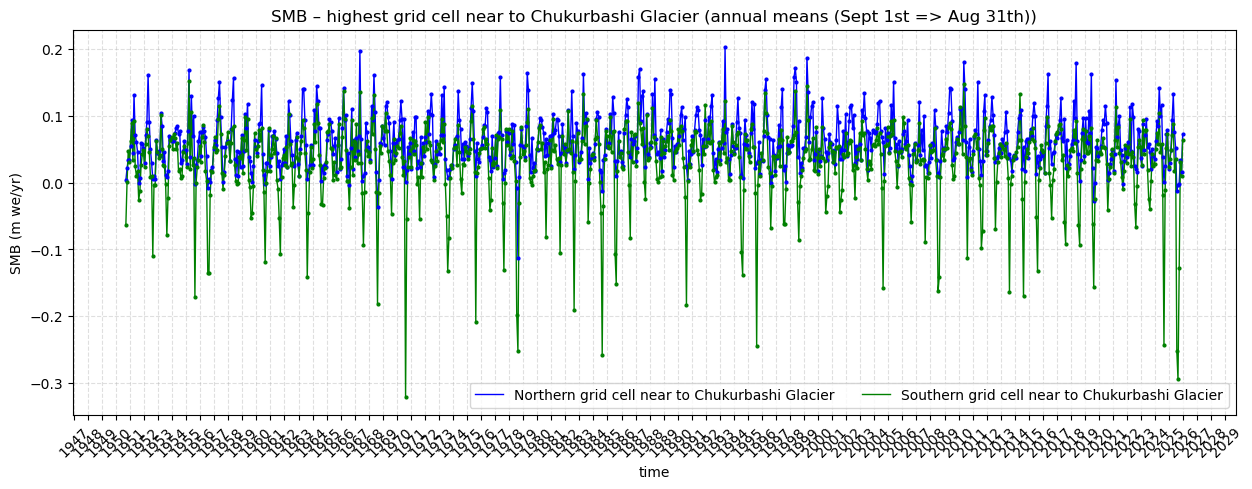

In [24]:
#SMB Annual (from Sept 1 to Aug 31)

plt.figure(figsize=(15,5))


ds_SMB_N = ds_SMB.isel(Y=iY_N, X=iX_N).sel(time=slice("1950-09-01", "2025-12-31"))/1000
ds_SMB_S = ds_SMB.isel(Y=iY_S, X=iX_S).sel(time=slice("1950-09-01", "2025-12-31"))/1000

ds_SMB_N.plot(label="Northern grid cell near to Chukurbashi Glacier", linewidth=1, color="blue")
ds_SMB_S.plot(label="Southern grid cell near to Chukurbashi Glacier", linewidth=1, color="green")



plt.plot(ds_SMB_N.time,
         ds_SMB_N,
         'o', color='blue', markersize=2)

plt.plot(ds_SMB_S.time,
         ds_SMB_S,
         'o', color='green', markersize=2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – highest grid cell near to Chukurbashi Glacier (annual means (Sept 1st => Aug 31th))")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

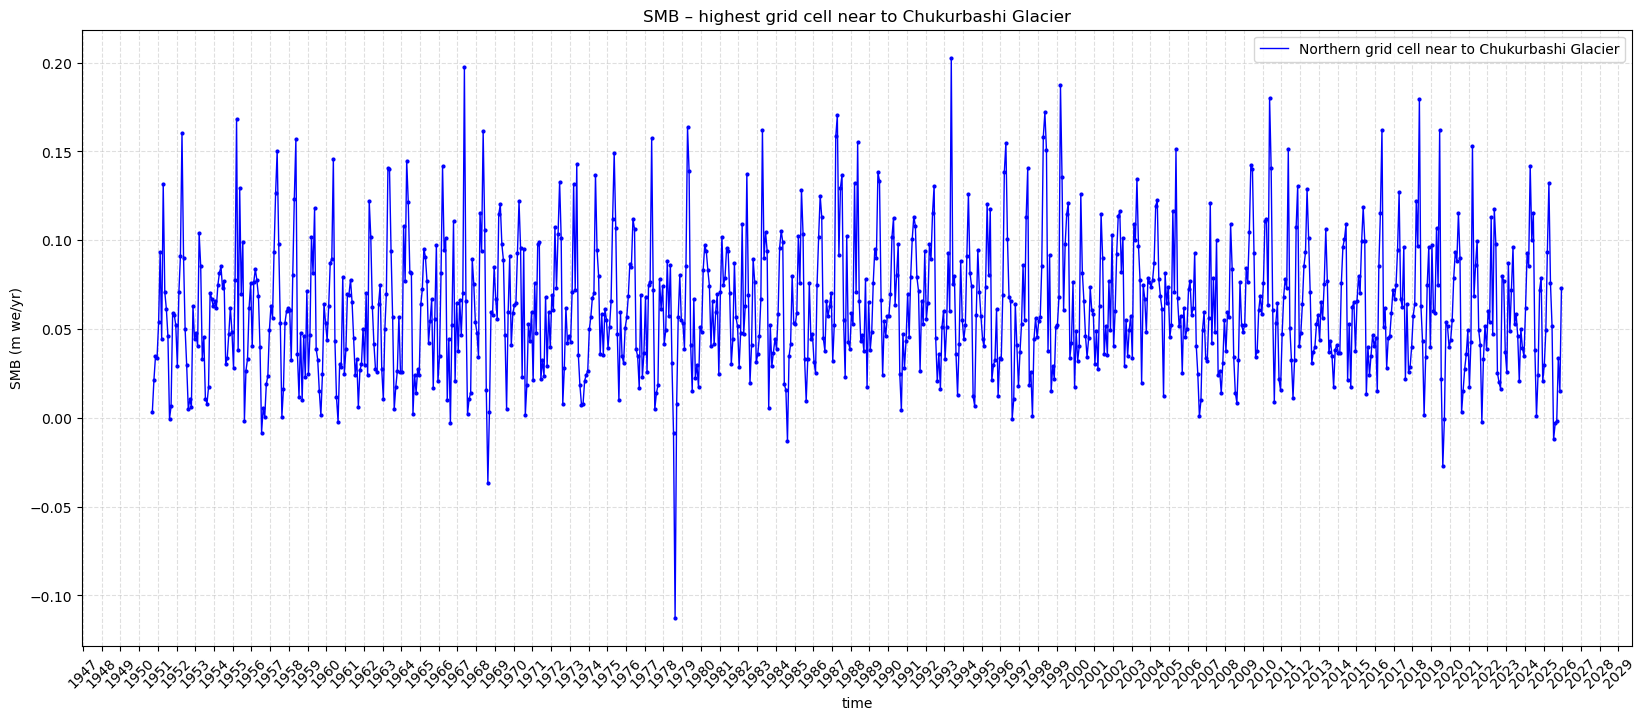

In [32]:
#SMB Annual (from Sept 1 to Aug 31)

plt.figure(figsize=(20,8))


ds_SMB_N = ds_SMB.isel(Y=iY_N, X=iX_N).sel(time=slice("1950-09-01", "2025-12-31"))/1000
# ds_SMB_S = ds_SMB.isel(Y=iY_S, X=iX_S).sel(time=slice("1950-09-01", "2025-12-31"))/1000

ds_SMB_N.plot(label="Northern grid cell near to Chukurbashi Glacier", linewidth=1, color="blue")
# ds_SMB_S.plot(label="Southern grid cell near to Chukurbashi Glacier", linewidth=1, color="green")



plt.plot(ds_SMB_N.time,
         ds_SMB_N,
         'o', color='blue', markersize=2)

# plt.plot(ds_SMB_S.time,
#          ds_SMB_S,
#          'o', color='green', markersize=2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("SMB – highest grid cell near to Chukurbashi Glacier")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()

In [174]:
ds_SMB_N.drop_vars(['X', 'Y', 'SECTOR']).to_series().to_csv("MAR_SMB_Chukurbashi.txt",sep="\t") 

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


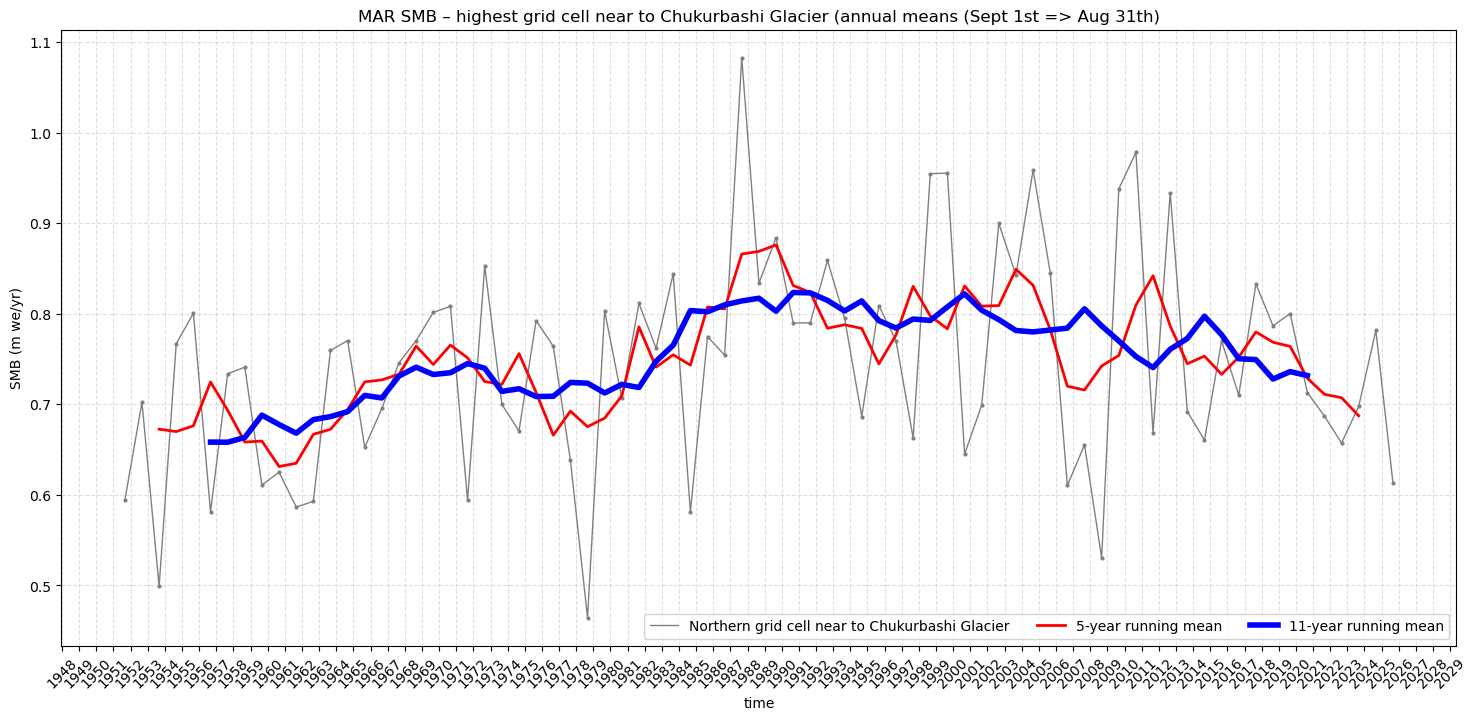

In [44]:
#SMB Annual (from Sept 1 to Aug 31)


ds_SMB_N = ds_SMB.isel(Y=iY_N, X=iX_N).sel(time=slice("1950-09-01", "2025-08-31")).resample(time="A-AUG").sum()/1000
# ds_SMB_S = ds_SMB.isel(Y=iY_S, X=iX_S).sel(time=slice("1950-09-01", "2025-12-31"))/1000

# Moyenne glissante sur 5 ans
ds_SMB_N_smooth_5 = ds_SMB_N.rolling(time=5, center=True).mean()

# Moyenne glissante sur 11 ans
ds_SMB_N_smooth_11 = ds_SMB_N.rolling(time=11, center=True).mean()


plt.figure(figsize=(18,8))



ds_SMB_N.plot(label="Northern grid cell near to Chukurbashi Glacier", linewidth=1, color="grey")
# ds_SMB_S.plot(label="Southern grid cell near to Chukurbashi Glacier", linewidth=1, color="green")

plt.plot(ds_SMB_N.time,
         ds_SMB_N,
         'o', color='grey', markersize=2)

ds_SMB_N_smooth_5.plot(label="5-year running mean", linewidth=2, color="red")
ds_SMB_N_smooth_11.plot(label="11-year running mean", linewidth=4, color="blue")

# plt.plot(ds_SMB_S.time,
#          ds_SMB_S,
#          'o', color='green', markersize=2)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.legend(ncol=3)
plt.title("MAR SMB – highest grid cell near to Chukurbashi Glacier (annual means (Sept 1st => Aug 31th)")
plt.ylabel("SMB (m we/yr)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.show()  

/home/fainx/micromamba/envs/Xav_2509/lib/python3.9/site-packages/xarray/groupers.py:326: FutureWarning: 'A-AUG' is deprecated and will be removed in a future version, please use 'YE-AUG' instead.
  self.index_grouper = pd.Grouper(


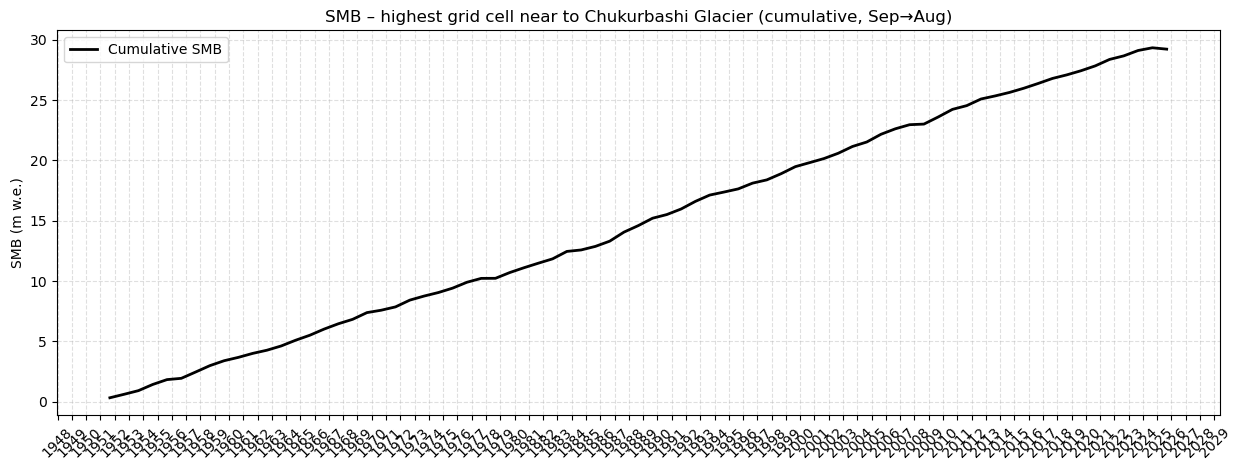

In [162]:
# =========================
# SMB annuel (Sep → Aug)
# =========================

ds_SMB_N = ds_SMB.isel(Y=iY_N, X=iX_N)
ds_SMB_N_annual = ds_SMB_N.resample(time="A-AUG").sum().sel(time=slice("1980-09-01", "2025-08-31"))/1000

# =========================
# CUMUL SMB
# =========================

ds_SMB_cum = ds_SMB_max_annual.cumsum(dim="time")

# =========================
# PLOT
# =========================

plt.figure(figsize=(15,5))

plt.plot(
    ds_SMB_cum.time,
    ds_SMB_cum,
    '-',
    color='black',
    linewidth=2,
    label="Cumulative SMB"
)

# =========================
# AXES
# =========================

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.YearLocator(1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

plt.title("SMB – highest grid cell near to Chukurbashi Glacier (cumulative, Sep→Aug)")
plt.ylabel("SMB (m w.e.)")

plt.grid(True, linestyle="--", alpha=0.4)
plt.legend()
plt.show()